# 2.1.2 让时间进入收支更新

## 学习目标与先修知识

能区分每步比例与每时间速率，把实际持续时间写入更新；用残差（residual）和独立累计账目检查实现。

先修：上一节的递推和有限求和，第 1 篇的单位与物质收支（mass balance）。 [复习上一节](01-从逐步变化到递推规则.ipynb)。

## 具体问题

向均匀物质池以 1 U/T 输入（input），同时以当前所追踪物质总量（tracked amount）的 0.5/T 清除。观察半个 T 和一个 T，能直接采用相同“每步清除比例”吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
A0, u, k = 2.0, 1.0, 0.5
rows = [(h, h*u, h*k*A0, A0+h*(u-k*A0)) for h in [.5,1,2]]
display(Markdown(show_table(['时长 / T','流入 / U','按段首计算的移除 / U','末量 / U'],rows)))

| 时长 / T | 流入 / U | 按段首计算的移除 / U | 末量 / U |
| --- | --- | --- | --- |
| 0.5 | 0.5 | 0.5 | 2 |
| 1 | 1 | 1 | 2 |
| 2 | 2 | 2 | 2 |

## 模型假设

物质池边界内混合均匀，没有空间分布、内部生成或额外通道。每段把流入速率 u 与段首清除速率 kA 保持不变。A 用 U，u 用 U/T，k 用 1/T，实际时长 h 用 T。

这可被定义为一种离散规则；若原问题是持续变化的清除，它只是“冻结段首速率”的近似。两种解释的假设必须先说清。

## 数学解释与推导

时间内搬运的总量是速率乘时长。因此
$$A_{n+1}=A_n+h(u-kA_n)=(1-kh)A_n+hu.$$
$kh$ 是无量纲（dimensionless）的**本步比例**，k 本身不是比例。与上一节对应，$q=1-kh$、$b=hu$。假如 h 改了，这两个每步量都要改。

若 k>0，不变状态（state）满足 $0=h(u-kA^*)$，得到 $A^*=u/k$，与 h 无关；但走向它的轨迹（trajectory）可能随 h 变化。k=0 时为逐段纯累积，无输入时则保持原量。

定义本步收支残差
$$r_n=A_{n+1}-A_n-hu+hkA_n.$$
按同一规则实现时它应只剩浮点舍入量。把所有步相加，也有 $A_N-A_0=\sum h u-\sum h k A_n$。第二项必须使用每一步当时的 A，而非同一个起点。

不等时长或变化输入时，直接替换为 $A_{n+1}=A_n+h_n(u_n-kA_n)$。$h_n$ 是这一段实际时长。负总量意味着假设或算法需要检查；把它裁成零会改写原账目。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def euler(A0, u, k, h, steps):
    amounts = [A0]
    residuals = []
    for _ in range(steps):
        before = amounts[-1]
        incoming = h * u
        removed = h * k * before
        after = before + incoming - removed
        amounts.append(after)
        residuals.append(after - before - incoming + removed)
    return amounts, residuals

def varying(A0, rates, durations, k):
    amounts, total = [A0], 0.0
    for rate, duration in zip(rates, durations):
        total += rate * duration
        amounts.append(amounts[-1] + duration * (rate - k * amounts[-1]))
    return amounts, total

## 对照实验

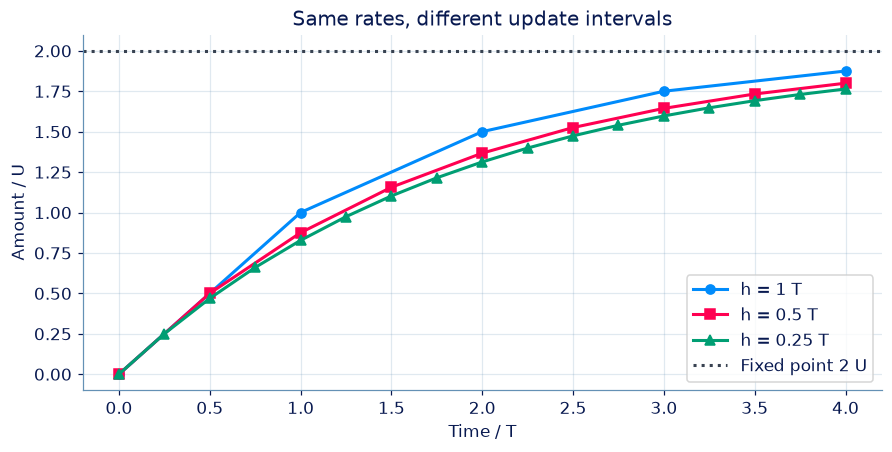

| 量 | 结果 |
| --- | --- |
| 逐段总量 / U | [1, 1.75, 0.875] |
| 总流入 / U | 1 |

In [4]:
fig, ax = plt.subplots()
for h, marker in [(1,'o'),(.5,'s'),(.25,'^')]:
    values, residuals = euler(0,1,.5,h,round(4/h))
    ax.plot(np.arange(len(values))*h,values,marker=marker,label=f'h = {h} T')
ax.axhline(2,color='#384251',ls=':',label='Fixed point 2 U')
ax.set(xlabel='Time / T',ylabel='Amount / U',title='Same rates, different update intervals')
ax.legend();plt.show()
varied,total = varying(1,[2,0],[.5,1],.5)
display(Markdown(show_table(['量','结果'], [('逐段总量 / U',varied),('总流入 / U',total)])))

## 结果解释

相同速率、相同总时长和起点下，三种离散轨迹不同，固定点（fixed point）却相同。不等时长例中，第一段末量 1.75 U，第二段末量 0.875 U；总流入 1 U 大于净增加，原因是同时发生清除。

### 独立核对

零残差只验证程序与账目一致；例如 −5 U 的失败结果也有零残差。后面将用连续解检查近似是否可信。

In [5]:
values,residuals=euler(0,1,.5,1,3)
np.testing.assert_allclose(values,[0,1,1.5,1.75])
assert max(map(abs,residuals))<1e-12
assert math.isclose(values[-1]-values[0],3*1-sum(.5*a for a in values[:-1]))
np.testing.assert_allclose(varying(2,[1,4,0],[.2,.8,.5],0)[0],[2,2.2,5.4,5.4])
assert euler(10,0,.75,2,1)[0][1] == -5
print('手算、累计账目、零清除和失败例均符合所声明更新式。')

手算、累计账目、零清除和失败例均符合所声明更新式。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/02-01-用递推描述增长与清除/explore/)：先预测改变一个条件后的结果，再回到这里对照推导与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：把每段流入和清除记到账上

人工单室模型（one-compartment model）在一段内用段首所追踪物质总量（tracked amount）计算清除速率 kA。实现更新，并返回每一步的收支（mass balance）残差（residual）。负结果保留，用于识别假设失败。

**函数与代码模板**

```python
def solve(
    A0: float,
    u: float,
    k: float,
    h: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `float` | 起点总量。 | U |
| `u` | `float` | 恒定流入速率。 | U/T |
| `k` | `float` | 每单位总量的清除速率系数。 | 1/T |
| `h` | `float` | 每步持续时间。 | T |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

按以下顺序返回元组：(amounts, residuals)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | 起点及逐步总量。 | U |
| `residuals` | `list[float]` | 每步末量减初量、减流入量、加清除量；长度 steps。 | U |

**计算规则**

after = before + h*u − h*k*before；残差 = after − before − h*u + h*k*before。不能用 after 代替清除项中的 before，也不裁剪负值。

**约束与边界**

- 所有数值有限；无需修改输入（input）。
- 0 ≤ A0,u ≤ 20；0 ≤ k ≤ 2；0 < h ≤ 3；0 ≤ steps ≤ 20；允许 kh > 1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 起点总量。 | 0 | U |
| u | 恒定流入速率。 | 1 | U/T |
| k | 每单位总量的清除速率系数。 | 0.5 | 1/T |
| h | 每步持续时间。 | 1 | T |
| steps | 更新次数。 | 3 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = 0
u = 1
k = 0.5
h = 1
steps = 3

result = solve(A0, u, k, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| amounts | 起点及逐步总量。 | [0, 1.0, 1.5, 1.75] | U |
| residuals | 每步末量减初量、减流入量、加清除量；长度 steps。 | [0.0, 0.0, 0.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0, 1.0, 1.5, 1.75], [0.0, 0.0, 0.0])
```

**样例解释**

前三步依次得到 1、1.5、1.75 U，返回总量 [0,1,1.5,1.75] 和三个零残差。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：把每段流入和清除记到账上](http://127.0.0.1:8000/chapters/02-01-%E7%94%A8%E9%80%92%E6%8E%A8%E6%8F%8F%E8%BF%B0%E5%A2%9E%E9%95%BF%E4%B8%8E%E6%B8%85%E9%99%A4/practice/?question=p02-euler-balance)

### 第 2 题 · 单项选择题：把速率转成每步比例

清除系数（elimination rate constant） k = 0.2 /T，段首所追踪物质总量（tracked amount）为 A，假设本段流出速率保持 kA。时间步长（time step） h = 0.5 T 时，本段移除多少？

- **A.** 0.2A U，与 h 无关。
- **B.** 0.1A U。
- **C.** 0.4A U。
- **D.** 0.5A U。

[作答：把速率转成每步比例](http://127.0.0.1:8000/chapters/02-01-%E7%94%A8%E9%80%92%E6%8E%A8%E6%8F%8F%E8%BF%B0%E5%A2%9E%E9%95%BF%E4%B8%8E%E6%B8%85%E9%99%A4/practice/?question=p02-rate-unit)

### 第 3 题 · Python 计算题：不等时长也要逐段记账

给定各段的流入速率和持续时间，清除速率在每段内固定为段首 kA。返回整条所追踪物质总量（tracked amount）轨迹（trajectory）和总流入量。

**函数与代码模板**

```python
def solve(
    A0: float,
    rates: list[float],
    durations: list[float],
    k: float,
) -> tuple[list[float], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `float` | 起点总量。 | U |
| `rates` | `list[float]` | 各段流入速率。 | U/T |
| `durations` | `list[float]` | 各段实际持续时间。 | T |
| `k` | `float` | 清除系数（elimination rate constant）。 | 1/T |

**返回值**

按以下顺序返回元组：(amounts, total)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | 含起点的逐段末量。 | U |
| `total` | `float` | 各段流入量之和。 | U |

**计算规则**

按给定顺序执行 A ← A + durations[i] × (rates[i] − kA)；total 为 sum(rates[i] × durations[i])。

**约束与边界**

- 所有数值有限；无需修改输入（input）。
- 两个列表等长，长度 0—100；0 ≤ A0,rates[i] ≤ 20；0 ≤ k ≤ 2；0 < durations[i] ≤ 2。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 起点总量。 | 1 | U |
| rates | 各段流入速率。 | [2, 0] | U/T |
| durations | 各段实际持续时间。 | [0.5, 1] | T |
| k | 清除系数（elimination rate constant）。 | 0.5 | 1/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = 1
rates = [2, 0]
durations = [0.5, 1]
k = 0.5

result = solve(A0, rates, durations, k)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| amounts | 含起点的逐段末量。 | [1, 1.75, 0.875] | U |
| total | 各段流入量之和。 | 1 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1, 1.75, 0.875], 1.0)
```

**样例解释**

第一段增加 0.5×(2−0.5×1)=0.75 U，第二段剩下 0.875 U；总流入为 1 U。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：不等时长也要逐段记账](http://127.0.0.1:8000/chapters/02-01-%E7%94%A8%E9%80%92%E6%8E%A8%E6%8F%8F%E8%BF%B0%E5%A2%9E%E9%95%BF%E4%B8%8E%E6%B8%85%E9%99%A4/practice/?question=p02-varying-steps)

### 第 4 题 · 多项选择题：零残差能证明什么

程序严格执行 A[n+1]=A[n]+h(u−kA[n])，各步收支（mass balance）残差（residual）约为零，但出现了 −5 U。哪些结论成立？

- **A.** 残差为零，说明负所追踪物质总量（tracked amount）一定真实。
- **B.** 残差只核对离散账目，不能替代物理合理性检查。
- **C.** 应直接把负值改为零，并继续声称同一更新式成立。
- **D.** 应检查步长和段内清除速率保持不变的假设。

[作答：零残差能证明什么](http://127.0.0.1:8000/chapters/02-01-%E7%94%A8%E9%80%92%E6%8E%A8%E6%8F%8F%E8%BF%B0%E5%A2%9E%E9%95%BF%E4%B8%8E%E6%B8%85%E9%99%A4/practice/?question=p02-balance-limit)

**进一步阅读**

[MIT 一阶微分方程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-i-first-order-differential-equations/)：后续连续时间建模与 Euler 方法。